# 03 — Logistic Regression & GLMs

**Covers concept IDs:** C2a (logit), C2b (probit), C3, C4, C5, C6a–c, C7.

## Learning outcomes
1. State the Bernoulli likelihood of a logistic / probit model.
2. Write the binomial deviance.
3. Derive the score $\partial\ell/\partial\beta$ for **both** logistic (sigmoid) and probit (Φ) links.
4. Interpret a logistic coefficient in **log-odds**, **odds**, and **marginal-probability** terms.
5. Describe probit as an alternative link and name a situation where it is preferred.
6. Extend to multinomial logistic (softmax) for >2 classes.
7. Write the gradient-descent update rule for logistic MLE.

## 1. Core formulas (reference)

**Bernoulli pmf.** $P(y_i\mid x_i,\beta) = p_i^{y_i}(1-p_i)^{1-y_i}$ with $p_i = f(x_i'\beta)$ for any link $f:\mathbb R\to(0,1)$.

**Logit link.** $f(z) = \sigma(z) = \dfrac{e^z}{1+e^z} = \dfrac{1}{1+e^{-z}}$.

**Probit link.** $f(z) = \Phi(z)$, CDF of $\mathcal N(0,1)$. Its derivative is $\phi(z) = \Phi'(z)$, the standard-normal pdf.

**Log-likelihood.** $\ell(\beta) = \sum_i\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big].$

**Deviance.** $\text{Dev}(\beta) = -2\ell(\beta).$

**Multinomial softmax (K classes).** $P(Y=k\mid X) = \dfrac{e^{x'\beta_k}}{\sum_{j=1}^K e^{x'\beta_j}}, \quad \hat y = \arg\max_k\, x'\beta_k.$

**Log-odds / logit.** $\text{logit}(p) = \log\dfrac{p}{1-p} = x'\beta.$

**Sigmoid derivative identity.** $\sigma'(z) = \sigma(z)\,(1-\sigma(z))$.

## 2. Derivation — logistic score function

Let $p_i = \sigma(x_i'\beta)$. By the sigmoid identity,
$$\frac{\partial p_i}{\partial\beta} = \sigma'(x_i'\beta)\cdot x_i = p_i(1-p_i)\,x_i.$$

Hence $\partial\log p_i/\partial\beta = (1-p_i)x_i$ and $\partial\log(1-p_i)/\partial\beta = -p_i\,x_i$.

Substitute into $\ell$:
$$\frac{\partial\ell}{\partial\beta} \;=\; \sum_{i=1}^n\big[y_i(1-p_i)x_i - (1-y_i)p_i\,x_i\big] \;=\; \sum_{i=1}^n (y_i - p_i)\,x_i.$$

The *gradient of the negative log-likelihood* is therefore
$$\nabla \text{Dev}(\beta) \;\propto\; \sum_{i=1}^n (p_i - y_i)\,x_i.$$

This is Assignment 2 Part B Q1 and the derivation you should be able to reproduce in **two lines**.

## 3. Derivation — probit score function (Midterm Practice 1.1.2)

Model: $p_i = \Phi(x_i'\beta)$, density $\phi(\cdot)=\Phi'(\cdot)$.

$$\frac{\partial p_i}{\partial\beta} = \phi(x_i'\beta)\,x_i,$$

and
$$\frac{\partial \log p_i}{\partial\beta} = \frac{\phi(x_i'\beta)}{\Phi(x_i'\beta)}\,x_i,\qquad
\frac{\partial \log(1-p_i)}{\partial\beta} = -\frac{\phi(x_i'\beta)}{1-\Phi(x_i'\beta)}\,x_i.$$

Substituting into $\ell$,
$$S(\beta) \;\equiv\; \frac{\partial\ell}{\partial\beta} \;=\; \sum_{i=1}^n\left[\frac{y_i\,\phi(x_i'\beta)}{\Phi(x_i'\beta)} - \frac{(1-y_i)\,\phi(x_i'\beta)}{1-\Phi(x_i'\beta)}\right] x_i.$$

Combining over a common denominator:
$$\boxed{\;S(\beta) \;=\; \sum_{i=1}^n \frac{\phi(x_i'\beta)\,\big(y_i - \Phi(x_i'\beta)\big)}{\Phi(x_i'\beta)\,(1-\Phi(x_i'\beta))}\,x_i\;}$$

which matches equation (2) of the practice short-answer.

## 4. Logit vs probit — when to prefer which?

Both links give very similar fits in practice. The key distinction is the *tail behaviour* / distributional assumption on the latent error:

- **Logit** is the CDF of a **Logistic(0, 1)** latent error.
- **Probit** is the CDF of a **Normal(0, 1)** latent error.

**Probit is preferred when** you want a *normally-distributed* latent index — natural if you believe the unobservables are aggregates of many independent additive shocks (CLT) or when embedding the model into a larger framework that uses Gaussian assumptions everywhere (e.g., bivariate probit with correlated residuals, Heckman selection).

**Logit is preferred when** you want the log-odds interpretation, or when you need the closed-form derivative identity (training is slightly faster and numerical).

## 5. Interpreting a logistic coefficient

If the fitted equation is $\log\dfrac{\hat p}{1-\hat p} = 0.5 + 0.7 x_1 - 1.2 x_2$, then:

| Quantity | Effect of a 1-unit ↑ in $x_1$ |
|---|---|
| Log-odds | ↑ by **0.7** |
| Odds | multiplied by $e^{0.7}\approx 2.01$ |
| Probability | **depends on baseline $p$** — not a fixed number |

The probability change depends on where on the sigmoid you start. Near $p=0.5$ the slope is $\sigma'(0)=1/4$, so a one-unit $x_1$ change shifts $p$ by $\approx 0.25 \cdot 0.7 = 0.175$. Deep in the tails, the change is much smaller.

**Common exam trap.** Answers like *"$\beta_1$ is the change in probability"* are **wrong** (Midterm Practice MC 3). The coefficient is the change in *log-odds*.

### Categorical logistic coefficients
If $x_1\in\{A,B,C\}$ with A dropped, then $\hat\beta_B = 0.7$ means *B-vs-A* odds are $e^{0.7}\approx 2.01$ times higher.

## 6. Multinomial logistic (softmax)

With $K$ classes we have $K$ coefficient vectors $\beta_1,\ldots,\beta_K$ (only $K-1$ identified; one is normalized to zero).
$$P(Y=k\mid x) = \frac{e^{x'\beta_k}}{\sum_{j=1}^K e^{x'\beta_j}}.$$
Prediction rule: $\hat y = \arg\max_k\, x'\beta_k$.

`sklearn.linear_model.LogisticRegression` automatically uses multinomial mode with >2 classes (Assignment 4 Q4 & Q5).

## 7. Gradient descent — how estimation actually happens

Unlike linear regression, logistic regression has **no closed-form MLE**. We iterate:
$$\beta_{t+1} = \beta_t - \eta\,\nabla\text{Dev}(\beta_t),$$
stopping when $\|\beta_{t+1}-\beta_t\|<\text{tol}$. Assignment 2 Part B implements exactly this for the single-predictor case and recovered $\hat\beta=1.02$ from true $\beta=1$.

Variants:
- **Batch GD** uses the full dataset each step.
- **Stochastic GD** uses one example.
- **Newton–Raphson** (aka IRLS) uses the second derivative; converges in far fewer steps.

## 8. Small code demo — logit vs probit look almost identical

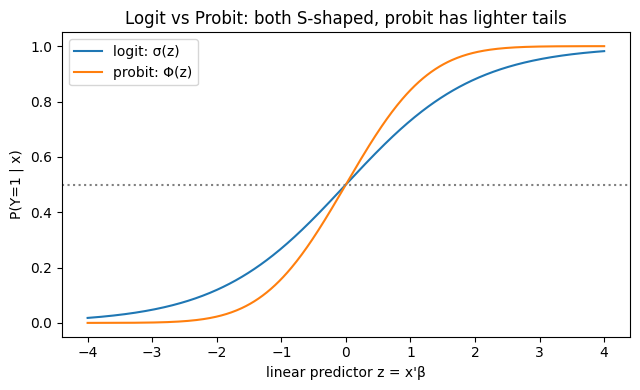

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

z = np.linspace(-4, 4, 500)
plt.figure(figsize=(6.5, 4))
plt.plot(z, 1/(1+np.exp(-z)), label='logit: σ(z)')
plt.plot(z, norm.cdf(z), label='probit: Φ(z)')
plt.axhline(0.5, color='grey', ls=':')
plt.xlabel('linear predictor z = x\'β'); plt.ylabel('P(Y=1 | x)')
plt.legend(); plt.title('Logit vs Probit: both S-shaped, probit has lighter tails')
plt.tight_layout(); plt.show()

## 9. Practice problems

### 9.1 MC style
> In logistic regression, coefficients represent: (A) changes in probability (B) changes in log-odds (C) changes in variance (D) marginal effects directly.

**Answer.** **(B) changes in log-odds.**

### 9.2 Log-odds arithmetic
> If $\hat\beta_1 = -0.4$, interpret the effect on odds of a one-unit increase in $x_1$.

**Answer.** Odds are multiplied by $e^{-0.4}\approx 0.67$ — a ~33% decrease in odds.

### 9.3 Score derivation
> Show the logistic score: $\partial\ell/\partial\beta = \sum_i(y_i-p_i)\,x_i$.

**Answer.** Use $\sigma'(z)=\sigma(z)(1-\sigma(z))$; obtain $\partial\log p_i/\partial\beta = (1-p_i)x_i$ and $\partial\log(1-p_i)/\partial\beta=-p_ix_i$. Sum weighted by $y_i,(1-y_i)$ — the cross terms cancel.

### 9.4 Probit advantage
> Give one reason to prefer probit over logit.

**Answer.** Probit assumes Gaussian latent errors, a natural choice when you want CLT-type error aggregation, or when combining with Gaussian selection / correlation models (e.g., Heckman two-stage).

### 9.5 Multinomial prediction
> Three classes (red, blue, green), with $x'\beta_{\text{red}}=1.2$, $x'\beta_{\text{blue}}=0.4$, $x'\beta_{\text{green}}=0.9$. Which class is predicted?

**Answer.** $\arg\max$ is **red** (1.2 > 0.9 > 0.4). The probabilities are $e^{1.2}/Z,\ e^{0.4}/Z,\ e^{0.9}/Z$ where $Z = e^{1.2}+e^{0.4}+e^{0.9}$.

### 9.6 Short
> In one sentence, why does logistic regression need gradient descent while linear regression does not?

**Answer.** The Gaussian log-likelihood is quadratic in $\beta$ (closed form via normal equations), but the Bernoulli log-likelihood is not — the score equation is nonlinear in $\beta$ and has no algebraic solution, so we must iterate.